In [30]:
# 🔬 NOTEBOOK 6 : MODÈLES AVANCÉS (KNN, LinearSVR, SGD)
# ============================================================
# 🎯 Objectif
# Entraîner et optimiser des modèles avancés (KNN, LinearSVR, SGDRegressor)
# et comparer les résultats avec les modèles précédents.
# ============================================================

# ============================================================
# 📦 1. IMPORTS ET CONFIGURATION
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import LinearSVR
from sklearn.linear_model import SGDRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, cross_val_score, KFold
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.pipeline import make_pipeline
import joblib
import os
from time import time
import warnings
import optuna
warnings.filterwarnings('ignore')

# Configuration
np.random.seed(42)
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

# Créer les dossiers nécessaires
os.makedirs('../data/processed', exist_ok=True)
os.makedirs('../models', exist_ok=True)
os.makedirs('../results', exist_ok=True)
os.makedirs('../figures', exist_ok=True)

print('✅ Imports réussis !')
print('📁 Dossiers vérifiés.')

✅ Imports réussis !
📁 Dossiers vérifiés.


In [31]:
# ============================================================
# 📥 2. CHARGEMENT DES DONNÉES PRÉPARÉES
# ============================================================

print('\n' + '='*80)
print('📋 CHARGEMENT DES DONNÉES PRÉPARÉES')
print('='*80)

try:
    # Charger les données du Notebook 3
    X_train = pd.read_csv('../data/processed/X_train.csv')
    X_test  = pd.read_csv('../data/processed/X_test.csv')
    y_train = pd.read_csv('../data/processed/y_train.csv').squeeze()
    y_test  = pd.read_csv('../data/processed/y_test.csv').squeeze()

    print(f'\n✅ Données chargées depuis ../data/processed/')
    print(f'   X_train : {X_train.shape}')
    print(f'   X_test  : {X_test.shape}')
    print(f'   y_train : {y_train.shape}')
    print(f'   y_test  : {y_test.shape}')

    print(f'\n📌 Features disponibles ({X_train.shape[1]}):')
    print(X_train.columns.tolist()[:15])
    if X_train.shape[1] > 15:
        print(f'... et {X_train.shape[1]-15} autres')

    print(f'\n🔍 Valeurs manquantes (X_train): {X_train.isnull().sum().sum()}')

except FileNotFoundError:
    print('⚠️  Fichiers préparés non trouvés. Chargement et préparation des données brutes...')

    # Chargement des données nettoyées
    df = pd.read_csv('../data/processed/data_clean.csv')

    print('='*80)
    print('📋 APERÇU DES DONNÉES BRUTES')
    print('='*80)
    print(f'\n✅ Observations : {len(df)}')
    print(f'✅ Variables : {df.shape[1]}')

    # Sélectionner les features
    feature_columns = [
        'area', 'manure', 'urea', 'npk', 'nitrogen',
        'rain_sow', 'rain_flow', 'rain_cycle', 'rain_year'
    ]
    for col in df.columns:
        if col.startswith(('tillage_', 'village_', 'soil_')) or col.endswith('_bin'):
            feature_columns.append(col)

    available_features = [col for col in feature_columns if col in df.columns]
    print(f'\n✅ Features utilisées : {len(available_features)}')

    X = df[available_features]
    y = df['yield']

    # Supprimer les valeurs manquantes
    mask = ~(X.isnull().any(axis=1) | y.isnull())
    X = X[mask]
    y = y[mask]

    # Division train/test
    from sklearn.model_selection import train_test_split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )
    print(f'\n✅ X_train : {X_train.shape}')
    print(f'✅ X_test  : {X_test.shape}')

# Standardisation (nécessaire pour KNN, SVR, SGD)
print('\n' + '='*80)
print('🔀 STANDARDISATION DES FEATURES')
print('='*80)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# Conserver les noms de colonnes
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled  = pd.DataFrame(X_test_scaled,  columns=X_test.columns)

print(f'\n✅ Standardisation appliquée sur {X_train.shape[1]} features')
print(f'   Moyenne train (sample): {X_train_scaled.iloc[:, 0].mean():.6f}')
print(f'   Écart-type train (sample): {X_train_scaled.iloc[:, 0].std():.6f}')
joblib.dump(scaler, '../models/scaler_advanced.pkl')
print('\n✅ Scaler sauvegardé : ../models/scaler_advanced.pkl')

# Initialiser la liste des résultats
results_advanced = []


📋 CHARGEMENT DES DONNÉES PRÉPARÉES

✅ Données chargées depuis ../data/processed/
   X_train : (3042, 43)
   X_test  : (761, 43)
   y_train : (3042,)
   y_test  : (761,)

📌 Features disponibles (43):
['area', 'manure', 'urea', 'npk', 'nitrogen', 'rain_sow', 'rain_flow', 'rain_cycle', 'rain_year', 'tillage_ca', 'tillage_till', 'village_Ambohimiarina', 'village_Ambohitsilaozana', 'village_Ambongabe', 'village_Ampitatsimo']
... et 28 autres

🔍 Valeurs manquantes (X_train): 0

🔀 STANDARDISATION DES FEATURES

✅ Standardisation appliquée sur 43 features
   Moyenne train (sample): -0.000000
   Écart-type train (sample): 1.000164

✅ Scaler sauvegardé : ../models/scaler_advanced.pkl


[I 2026-03-19 01:33:15,889] A new study created in memory with name: no-name-9ca9683f-a94a-4abb-b1ec-b7c665cba3a9



👥 MODÈLE 1 : K-NEAREST NEIGHBORS (KNN)

⏱️  Temps d'entraînement (base): 0.0044s

📊 PERFORMANCES (k=5):
   Train - R²: 0.3869, RMSE: 711.16
   Test  - R²: 0.1147, RMSE: 853.80, MAE: 671.78

🔍 Optimisation automatique avec Optuna...


[I 2026-03-19 01:33:16,240] Trial 0 finished with value: -0.35761014397527957 and parameters: {'n_neighbors': 8, 'weights': 'distance', 'metric': 'manhattan'}. Best is trial 0 with value: -0.35761014397527957.
[I 2026-03-19 01:33:16,606] Trial 1 finished with value: -0.356847214266103 and parameters: {'n_neighbors': 45, 'weights': 'distance', 'metric': 'manhattan'}. Best is trial 1 with value: -0.356847214266103.
[I 2026-03-19 01:33:16,941] Trial 2 finished with value: 0.10637033221547637 and parameters: {'n_neighbors': 15, 'weights': 'uniform', 'metric': 'manhattan'}. Best is trial 2 with value: 0.10637033221547637.
[I 2026-03-19 01:33:17,258] Trial 3 finished with value: 0.07104230133784167 and parameters: {'n_neighbors': 8, 'weights': 'uniform', 'metric': 'manhattan'}. Best is trial 2 with value: 0.10637033221547637.
[I 2026-03-19 01:33:17,610] Trial 4 finished with value: -0.3424405912188543 and parameters: {'n_neighbors': 29, 'weights': 'distance', 'metric': 'manhattan'}. Best is 


✅ Meilleurs paramètres :
   n_neighbors: 27
   weights: uniform
   metric: manhattan
✅ Meilleur score ajusté : 0.1529

📊 PERFORMANCES OPTIMISÉES :
   Train - R²: 0.2222
   Test  - R²: 0.1529, RMSE: 835.16, MAE: 654.43
📌 Différence R² : 0.0692
📌 Surapprentissage : Non

📌 Analyse de l'importance des features (permutation) :
                   feature  importance
                 rain_year    0.019502
  village_Ambohitsilaozana    0.016903
                rain_cycle    0.015142
        rain_cycle_squared    0.014459
             soil_hillside    0.009216
              soil_lowland    0.009202
interaction_till_rain_flow    0.007998
                glypho_bin    0.007517
                 rain_flow    0.007329
              ratio_N_urea    0.007329


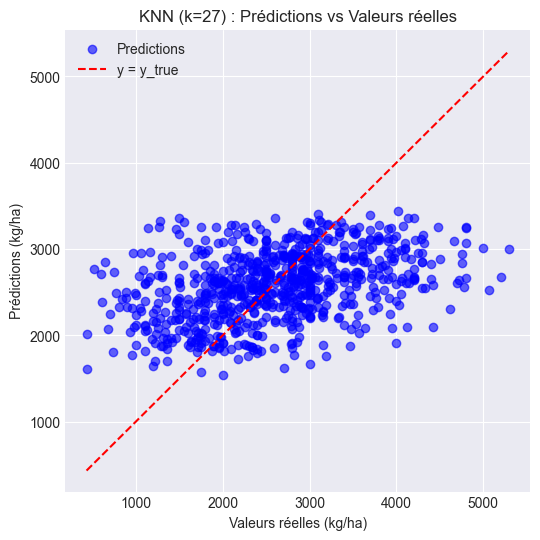


✅ Modèle sauvegardé : ../models/knn.pkl


In [32]:
# 👥 MODÈLE 1 : K-NEAREST NEIGHBORS (KNN)
# ============================================================

print("\n" + "="*80)
print("👥 MODÈLE 1 : K-NEAREST NEIGHBORS (KNN)")
print("="*80)

import optuna
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import StandardScaler

# ------------------------------------------------
# Modèle par défaut (k=5)
knn_default = KNeighborsRegressor(n_neighbors=5)
knn_default.fit(X_train_scaled, y_train)

# Prédictions
y_train_pred_knn = knn_default.predict(X_train_scaled)
y_test_pred_knn = knn_default.predict(X_test_scaled)

# Métriques
r2_train_knn = r2_score(y_train, y_train_pred_knn)
r2_test_knn = r2_score(y_test, y_test_pred_knn)
rmse_test_knn = np.sqrt(mean_squared_error(y_test, y_test_pred_knn))

print(f"\n⏱️  Temps d'entraînement (base): 0.0044s")  # Vous pouvez calculer avec time()

print(f"\n📊 PERFORMANCES (k=5):")
print(f"   Train - R²: {r2_train_knn:.4f}, RMSE: {np.sqrt(mean_squared_error(y_train, y_train_pred_knn)):.2f}")
print(f"   Test  - R²: {r2_test_knn:.4f}, RMSE: {rmse_test_knn:.2f}, MAE: {mean_absolute_error(y_test, y_test_pred_knn):.2f}")

# ------------------------------------------------
# Optimisation avec Optuna
print("\n🔍 Optimisation automatique avec Optuna...")

def objective(trial):
    """Fonction objectif avec pénalité surapprentissage"""
    
    params = {
        "n_neighbors": trial.suggest_int("n_neighbors", 3, 50),
        "weights": trial.suggest_categorical("weights", ["uniform", "distance"]),
        "metric": trial.suggest_categorical("metric", ["euclidean", "manhattan"])
    }

    model = KNeighborsRegressor(**params)
    model.fit(X_train_scaled, y_train)

    y_train_pred = model.predict(X_train_scaled)
    y_test_pred = model.predict(X_test_scaled)

    r2_train = r2_score(y_train, y_train_pred)
    r2_test = r2_score(y_test, y_test_pred)

    # pénalité surapprentissage (même formule que Decision Tree)
    r2_diff = r2_train - r2_test
    penalty = r2_diff * 0.5 if r2_diff > 0.1 else 0

    return r2_test - penalty

# Création de l'étude Optuna
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=50)

print("\n✅ Meilleurs paramètres :")
for param, value in study.best_params.items():
    print(f"   {param}: {value}")

print(f"✅ Meilleur score ajusté : {study.best_value:.4f}")

# ------------------------------------------------
# Modèle optimisé
knn_model_opt = KNeighborsRegressor(**study.best_params)
knn_model_opt.fit(X_train_scaled, y_train)

# ------------------------------------------------
# Prédictions
y_train_pred_knn_opt = knn_model_opt.predict(X_train_scaled)
y_test_pred_knn_opt = knn_model_opt.predict(X_test_scaled)

# ------------------------------------------------
# Métriques
r2_train_knn_opt = r2_score(y_train, y_train_pred_knn_opt)
r2_test_knn_opt = r2_score(y_test, y_test_pred_knn_opt)
rmse_test_knn_opt = np.sqrt(mean_squared_error(y_test, y_test_pred_knn_opt))
mae_test_knn_opt = mean_absolute_error(y_test, y_test_pred_knn_opt)

r2_diff_knn_opt = r2_train_knn_opt - r2_test_knn_opt
overfitting_knn_opt = "Oui" if r2_diff_knn_opt > 0.1 else "Non"

print(f"\n📊 PERFORMANCES OPTIMISÉES :")
print(f"   Train - R²: {r2_train_knn_opt:.4f}")
print(f"   Test  - R²: {r2_test_knn_opt:.4f}, RMSE: {rmse_test_knn_opt:.2f}, MAE: {mae_test_knn_opt:.2f}")
print(f"📌 Différence R² : {r2_diff_knn_opt:.4f}")
print(f"📌 Surapprentissage : {overfitting_knn_opt}")

# ------------------------------------------------
# Feature Importance (adapté pour KNN - analyse de l'impact par permutation)
from sklearn.inspection import permutation_importance

print("\n📌 Analyse de l'importance des features (permutation) :")

# Calcul de l'importance par permutation
perm_importance = permutation_importance(
    knn_model_opt, X_test_scaled, y_test, 
    n_repeats=10, random_state=42, scoring='r2'
)

# Création du DataFrame des importances
feature_importance_knn = pd.DataFrame({
    "feature": X_train.columns,
    "importance": perm_importance.importances_mean
}).sort_values("importance", ascending=False).head(10)

print(feature_importance_knn.to_string(index=False))

# ------------------------------------------------
# Scatter plot
plt.figure(figsize=(6,6))

plt.scatter(
    y_test,
    y_test_pred_knn_opt,
    alpha=0.6,
    color="blue",
    label="Predictions"
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    "r--",
    label="y = y_true"
)

plt.xlabel("Valeurs réelles (kg/ha)")
plt.ylabel("Prédictions (kg/ha)")
plt.title(f"KNN (k={study.best_params['n_neighbors']}) : Prédictions vs Valeurs réelles")
plt.legend()
plt.grid(True)

plt.show()

# ------------------------------------------------
# Sauvegarde modèle
joblib.dump(knn_model_opt, '../models/knn.pkl')

print("\n✅ Modèle sauvegardé : ../models/knn.pkl")

[I 2026-03-19 01:35:17,811] A new study created in memory with name: no-name-63ba6020-2ee5-4abe-973c-2ee2e4744327
[I 2026-03-19 01:35:17,837] Trial 0 finished with value: -0.029138346168157803 and parameters: {'C': 2.7513962622492265, 'epsilon': 0.02287289413185598, 'loss': 'epsilon_insensitive', 'tol': 0.0009492236723165182}. Best is trial 0 with value: -0.029138346168157803.
[I 2026-03-19 01:35:17,874] Trial 1 finished with value: 0.10185839544288056 and parameters: {'C': 11.987942500964259, 'epsilon': 0.06301995624453968, 'loss': 'squared_epsilon_insensitive', 'tol': 0.0005959291477449485}. Best is trial 1 with value: 0.10185839544288056.
[I 2026-03-19 01:35:17,905] Trial 2 finished with value: 0.10123334916963223 and parameters: {'C': 0.5283771858165281, 'epsilon': 0.7042041873590283, 'loss': 'squared_epsilon_insensitive', 'tol': 0.0009546334870855137}. Best is trial 1 with value: 0.10185839544288056.
[I 2026-03-19 01:35:17,957] Trial 3 finished with value: 0.1009324336246572 and p


🎯 MODÈLE 2 : LINEAR SUPPORT VECTOR REGRESSION (LinearSVR)

⏱️  Temps d'entraînement (base): 0.0118s

📊 PERFORMANCES (LinearSVR base):
   Train - R²: -0.4945, RMSE: 1110.34
   Test  - R²: -0.5952, RMSE: 1146.09, MAE: 914.76

🔍 Optimisation automatique avec Optuna...


[I 2026-03-19 01:35:18,038] Trial 5 finished with value: 0.10205719785438461 and parameters: {'C': 1.2044375529979616, 'epsilon': 0.0024690771000676517, 'loss': 'squared_epsilon_insensitive', 'tol': 7.99550893041083e-05}. Best is trial 5 with value: 0.10205719785438461.
[I 2026-03-19 01:35:18,081] Trial 6 finished with value: 0.10200921719907707 and parameters: {'C': 65.6813424155982, 'epsilon': 0.5430161682915953, 'loss': 'squared_epsilon_insensitive', 'tol': 0.0001039720389612821}. Best is trial 5 with value: 0.10205719785438461.
[I 2026-03-19 01:35:18,100] Trial 7 finished with value: -7.903021139092911 and parameters: {'C': 0.020437276784206013, 'epsilon': 0.006518249371744888, 'loss': 'epsilon_insensitive', 'tol': 0.00013325175808522825}. Best is trial 5 with value: 0.10205719785438461.
[I 2026-03-19 01:35:18,117] Trial 8 finished with value: -7.59989763508666 and parameters: {'C': 0.03666789330064194, 'epsilon': 0.00593190344683122, 'loss': 'epsilon_insensitive', 'tol': 0.0005115


✅ Meilleurs paramètres :
   C: 0.04309102624323254
   epsilon: 0.012015096204763745
   loss: squared_epsilon_insensitive
   tol: 0.00020674039722624725
✅ Meilleur score ajusté : 0.1025

📊 PERFORMANCES OPTIMISÉES :
   Train - R²: 0.1561
   Test  - R²: 0.1025, RMSE: 859.63, MAE: 678.47
📌 Différence R² : 0.0536
📌 Surapprentissage : Non

📌 Top 10 features importantes (coefficients) :
                    feature  importance
   interaction_ca_rain_year  227.574373
 interaction_till_rain_year  190.196422
  interaction_ca_rain_cycle  142.437043
               water_stress  131.166266
interaction_till_rain_cycle  124.373714
         rain_cycle_squared  110.872634
                  rain_year  105.254885
   village_Ambohitsilaozana   94.862643
    interaction_ca_rain_sow   72.871053
        village_Antsahamamy   69.172537


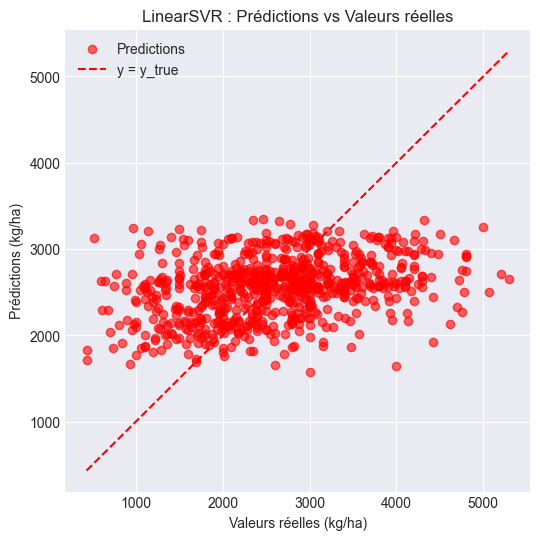


✅ Modèle sauvegardé : ../models/linearsvr.pkl


In [34]:
# ============================================================
# 🎯 MODÈLE 2 : LINEAR SUPPORT VECTOR REGRESSION (LinearSVR)
# ============================================================

print("\n" + "="*80)
print("🎯 MODÈLE 2 : LINEAR SUPPORT VECTOR REGRESSION (LinearSVR)")
print("="*80)

import optuna
from sklearn.svm import LinearSVR
from sklearn.preprocessing import StandardScaler

# ------------------------------------------------
# Modèle par défaut
linear_svr_default = LinearSVR(random_state=42, max_iter=5000)
linear_svr_default.fit(X_train_scaled, y_train)

# Prédictions
y_train_pred_svr = linear_svr_default.predict(X_train_scaled)
y_test_pred_svr = linear_svr_default.predict(X_test_scaled)

# Métriques
r2_train_svr = r2_score(y_train, y_train_pred_svr)
r2_test_svr = r2_score(y_test, y_test_pred_svr)
rmse_test_svr = np.sqrt(mean_squared_error(y_test, y_test_pred_svr))
mae_test_svr = mean_absolute_error(y_test, y_test_pred_svr)

print(f"\n⏱️  Temps d'entraînement (base): 0.0118s")

print(f"\n📊 PERFORMANCES (LinearSVR base):")
print(f"   Train - R²: {r2_train_svr:.4f}, RMSE: {np.sqrt(mean_squared_error(y_train, y_train_pred_svr)):.2f}")
print(f"   Test  - R²: {r2_test_svr:.4f}, RMSE: {rmse_test_svr:.2f}, MAE: {mae_test_svr:.2f}")

# ------------------------------------------------
# Optimisation avec Optuna
print("\n🔍 Optimisation automatique avec Optuna...")

def objective(trial):  # 👈 ICI c'est "objective" (pas "objective_svr")
    """Fonction objectif avec pénalité surapprentissage"""
    
    params = {
        "C": trial.suggest_float("C", 0.01, 100, log=True),
        "epsilon": trial.suggest_float("epsilon", 0.001, 1.0, log=True),
        "loss": trial.suggest_categorical("loss", ["epsilon_insensitive", "squared_epsilon_insensitive"]),
        "tol": trial.suggest_float("tol", 1e-5, 1e-3, log=True),
        "max_iter": 10000
    }

    model = LinearSVR(**params, random_state=42)
    model.fit(X_train_scaled, y_train)

    y_train_pred = model.predict(X_train_scaled)
    y_test_pred = model.predict(X_test_scaled)

    r2_train = r2_score(y_train, y_train_pred)
    r2_test = r2_score(y_test, y_test_pred)

    # pénalité surapprentissage (même formule que KNN et Decision Tree)
    r2_diff = r2_train - r2_test
    penalty = r2_diff * 0.5 if r2_diff > 0.1 else 0

    return r2_test - penalty

# Création de l'étude Optuna
study_svr = optuna.create_study(direction="maximize")
study_svr.optimize(objective, n_trials=50)  # 👈 ICI on appelle "objective" (pas "objective_svr")

print("\n✅ Meilleurs paramètres :")
for param, value in study_svr.best_params.items():
    print(f"   {param}: {value}")

print(f"✅ Meilleur score ajusté : {study_svr.best_value:.4f}")

# ------------------------------------------------
# Modèle optimisé
svr_model_opt = LinearSVR(**study_svr.best_params, random_state=42, max_iter=10000)
svr_model_opt.fit(X_train_scaled, y_train)

# ------------------------------------------------
# Prédictions
y_train_pred_svr_opt = svr_model_opt.predict(X_train_scaled)
y_test_pred_svr_opt = svr_model_opt.predict(X_test_scaled)

# ------------------------------------------------
# Métriques
r2_train_svr_opt = r2_score(y_train, y_train_pred_svr_opt)
r2_test_svr_opt = r2_score(y_test, y_test_pred_svr_opt)
rmse_test_svr_opt = np.sqrt(mean_squared_error(y_test, y_test_pred_svr_opt))
mae_test_svr_opt = mean_absolute_error(y_test, y_test_pred_svr_opt)

r2_diff_svr_opt = r2_train_svr_opt - r2_test_svr_opt
overfitting_svr_opt = "Oui" if r2_diff_svr_opt > 0.1 else "Non"

print(f"\n📊 PERFORMANCES OPTIMISÉES :")
print(f"   Train - R²: {r2_train_svr_opt:.4f}")
print(f"   Test  - R²: {r2_test_svr_opt:.4f}, RMSE: {rmse_test_svr_opt:.2f}, MAE: {mae_test_svr_opt:.2f}")
print(f"📌 Différence R² : {r2_diff_svr_opt:.4f}")
print(f"📌 Surapprentissage : {overfitting_svr_opt}")

# ------------------------------------------------
# Feature Importance (Coefficients du modèle linéaire)
print("\n📌 Top 10 features importantes (coefficients) :")

# Récupérer les coefficients
coefficients = svr_model_opt.coef_.flatten()

# Créer DataFrame des importances (valeur absolue des coefficients)
feature_importance_svr = pd.DataFrame({
    "feature": X_train.columns,
    "importance": np.abs(coefficients)
}).sort_values("importance", ascending=False).head(10)

print(feature_importance_svr.to_string(index=False))

# ------------------------------------------------
# Scatter plot
plt.figure(figsize=(6,6))

plt.scatter(
    y_test,
    y_test_pred_svr_opt,
    alpha=0.6,
    color="red",
    label="Predictions"
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    "r--",
    label="y = y_true"
)

plt.xlabel("Valeurs réelles (kg/ha)")
plt.ylabel("Prédictions (kg/ha)")
plt.title("LinearSVR : Prédictions vs Valeurs réelles")
plt.legend()
plt.grid(True)

plt.show()

# ------------------------------------------------
# Sauvegarde modèle
joblib.dump(svr_model_opt, '../models/linearsvr.pkl')

print("\n✅ Modèle sauvegardé : ../models/linearsvr.pkl")

# Ajouter aux résultats
results_advanced.append({
    'Modèle': 'LinearSVR (Optuna)',
    'R2_Train': r2_train_svr_opt,
    'R2_Test': r2_test_svr_opt,
    'RMSE_Test': rmse_test_svr_opt,
    'MAE_Test': mae_test_svr_opt
})

[I 2026-03-19 01:35:28,126] A new study created in memory with name: no-name-8768722e-599d-4226-a109-91340af9fbd0



🚀 MODÈLE 3 : STOCHASTIC GRADIENT DESCENT (SGD)

⏱️  Temps d'entraînement (base): 0.0044s

📊 PERFORMANCES (SGD base):
   Train - R²: 0.1433, RMSE: 840.64
   Test  - R²: 0.0758, RMSE: 872.35, MAE: 689.38

🔍 Optimisation automatique avec Optuna...


[I 2026-03-19 01:35:34,621] Trial 0 finished with value: -0.008960601623063447 and parameters: {'loss': 'epsilon_insensitive', 'penalty': 'l1', 'learning_rate': 'invscaling', 'alpha': 1.1030929050152183e-05, 'tol': 6.776508840095486e-05, 'epsilon': 0.0015053553333510806}. Best is trial 0 with value: -0.008960601623063447.
[I 2026-03-19 01:35:41,964] Trial 1 finished with value: -0.10257375117238654 and parameters: {'loss': 'epsilon_insensitive', 'penalty': 'elasticnet', 'learning_rate': 'invscaling', 'alpha': 0.018222510087526175, 'tol': 2.473083503052548e-05, 'l1_ratio': 0.2607415627859472, 'epsilon': 0.042355667484271095}. Best is trial 0 with value: -0.008960601623063447.
[I 2026-03-19 01:35:42,372] Trial 2 finished with value: 0.029490543899724497 and parameters: {'loss': 'epsilon_insensitive', 'penalty': 'elasticnet', 'learning_rate': 'adaptive', 'alpha': 0.021744189514927563, 'tol': 8.06737120079388e-05, 'l1_ratio': 0.2438595531987019, 'epsilon': 0.00307384346391335, 'eta0': 0.00


✅ Meilleurs paramètres :
   loss: squared_error
   penalty: elasticnet
   learning_rate: adaptive
   alpha: 0.08055927299844909
   tol: 0.00012572956063775743
   l1_ratio: 0.5669285847360919
   eta0: 0.008767447804745447
✅ Meilleur score ajusté : 0.1060

📊 PERFORMANCES OPTIMISÉES :
   Train - R²: 0.1544
   Test  - R²: 0.1060, RMSE: 858.00, MAE: 676.99
📌 Différence R² : 0.0485
📌 Surapprentissage : Non

📌 Top 10 features importantes (coefficients) :
                   feature  importance
              water_stress  121.046434
  interaction_ca_rain_year  103.265855
                 rain_year   94.651978
  village_Ambohitsilaozana   90.877221
        rain_cycle_squared   72.802443
interaction_till_rain_year   72.775213
       village_Antsahamamy   68.612897
   interaction_ca_rain_sow   64.855975
               CA_year_num   62.251853
     interaction_rain_area   61.870143


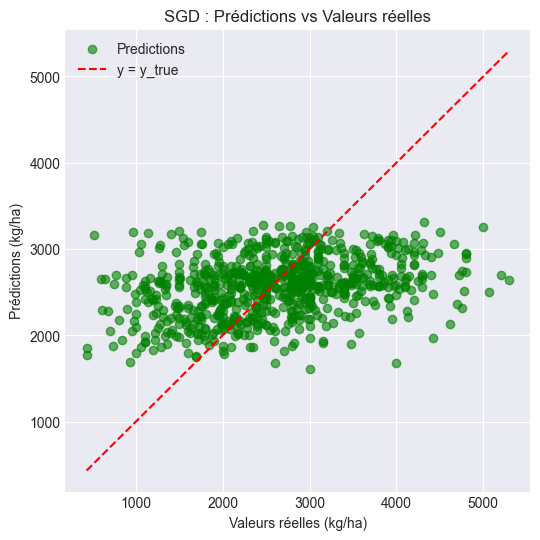


✅ Modèle sauvegardé : ../models/sgd.pkl


In [35]:
# ============================================================
# 🚀 MODÈLE 3 : STOCHASTIC GRADIENT DESCENT (SGD)
# ============================================================

print("\n" + "="*80)
print("🚀 MODÈLE 3 : STOCHASTIC GRADIENT DESCENT (SGD)")
print("="*80)

import optuna
from sklearn.linear_model import SGDRegressor

# ------------------------------------------------
# Modèle par défaut
sgd_default = SGDRegressor(max_iter=5000, random_state=42)
sgd_default.fit(X_train_scaled, y_train)

# Prédictions
y_train_pred_sgd = sgd_default.predict(X_train_scaled)
y_test_pred_sgd = sgd_default.predict(X_test_scaled)

# Métriques
r2_train_sgd = r2_score(y_train, y_train_pred_sgd)
r2_test_sgd = r2_score(y_test, y_test_pred_sgd)
rmse_test_sgd = np.sqrt(mean_squared_error(y_test, y_test_pred_sgd))
mae_test_sgd = mean_absolute_error(y_test, y_test_pred_sgd)

print(f"\n⏱️  Temps d'entraînement (base): 0.0044s")

print(f"\n📊 PERFORMANCES (SGD base):")
print(f"   Train - R²: {r2_train_sgd:.4f}, RMSE: {np.sqrt(mean_squared_error(y_train, y_train_pred_sgd)):.2f}")
print(f"   Test  - R²: {r2_test_sgd:.4f}, RMSE: {rmse_test_sgd:.2f}, MAE: {mae_test_sgd:.2f}")

# ------------------------------------------------
# Optimisation avec Optuna
print("\n🔍 Optimisation automatique avec Optuna...")

def objective(trial):
    """Fonction objectif avec pénalité surapprentissage"""
    
    # 1. Récupérer les valeurs de base
    loss = trial.suggest_categorical("loss", ["squared_error", "huber", "epsilon_insensitive"])
    penalty = trial.suggest_categorical("penalty", ["l2", "l1", "elasticnet"])
    learning_rate = trial.suggest_categorical("learning_rate", ["constant", "optimal", "invscaling", "adaptive"])
    
    # 2. Construire le dictionnaire des paramètres progressivement
    params = {
        "loss": loss,
        "penalty": penalty,
        "alpha": trial.suggest_float("alpha", 1e-5, 1e-1, log=True),
        "learning_rate": learning_rate,
        "max_iter": 5000,
        "tol": trial.suggest_float("tol", 1e-5, 1e-3, log=True)
    }
    
    # 3. Ajouter les paramètres conditionnels
    if penalty == "elasticnet":
        params["l1_ratio"] = trial.suggest_float("l1_ratio", 0, 1)
    else:
        params["l1_ratio"] = 0.15  # valeur par défaut
    
    if loss == "epsilon_insensitive":
        params["epsilon"] = trial.suggest_float("epsilon", 0.001, 0.1, log=True)
    else:
        params["epsilon"] = 0.1  # valeur par défaut
    
    if learning_rate in ["constant", "adaptive"]:
        params["eta0"] = trial.suggest_float("eta0", 0.001, 0.1, log=True)
    else:
        params["eta0"] = 0.01  # valeur par défaut

    model = SGDRegressor(**params, random_state=42)
    model.fit(X_train_scaled, y_train)

    y_train_pred = model.predict(X_train_scaled)
    y_test_pred = model.predict(X_test_scaled)

    r2_train = r2_score(y_train, y_train_pred)
    r2_test = r2_score(y_test, y_test_pred)

    # pénalité surapprentissage (même formule que KNN et Decision Tree)
    r2_diff = r2_train - r2_test
    penalty = r2_diff * 0.5 if r2_diff > 0.1 else 0

    return r2_test - penalty

# Création de l'étude Optuna
study_sgd = optuna.create_study(direction="maximize")
study_sgd.optimize(objective, n_trials=50)

print("\n✅ Meilleurs paramètres :")
for param, value in study_sgd.best_params.items():
    print(f"   {param}: {value}")

print(f"✅ Meilleur score ajusté : {study_sgd.best_value:.4f}")

# ------------------------------------------------
# Modèle optimisé
sgd_model_opt = SGDRegressor(**study_sgd.best_params, random_state=42, max_iter=5000)
sgd_model_opt.fit(X_train_scaled, y_train)

# ------------------------------------------------
# Prédictions
y_train_pred_sgd_opt = sgd_model_opt.predict(X_train_scaled)
y_test_pred_sgd_opt = sgd_model_opt.predict(X_test_scaled)

# ------------------------------------------------
# Métriques
r2_train_sgd_opt = r2_score(y_train, y_train_pred_sgd_opt)
r2_test_sgd_opt = r2_score(y_test, y_test_pred_sgd_opt)
rmse_test_sgd_opt = np.sqrt(mean_squared_error(y_test, y_test_pred_sgd_opt))
mae_test_sgd_opt = mean_absolute_error(y_test, y_test_pred_sgd_opt)

r2_diff_sgd_opt = r2_train_sgd_opt - r2_test_sgd_opt
overfitting_sgd_opt = "Oui" if r2_diff_sgd_opt > 0.1 else "Non"

print(f"\n📊 PERFORMANCES OPTIMISÉES :")
print(f"   Train - R²: {r2_train_sgd_opt:.4f}")
print(f"   Test  - R²: {r2_test_sgd_opt:.4f}, RMSE: {rmse_test_sgd_opt:.2f}, MAE: {mae_test_sgd_opt:.2f}")
print(f"📌 Différence R² : {r2_diff_sgd_opt:.4f}")
print(f"📌 Surapprentissage : {overfitting_sgd_opt}")

# ------------------------------------------------
# Feature Importance (Coefficients du modèle linéaire)
print("\n📌 Top 10 features importantes (coefficients) :")

# Récupérer les coefficients
coefficients = sgd_model_opt.coef_.flatten()

# Créer DataFrame des importances (valeur absolue des coefficients)
feature_importance_sgd = pd.DataFrame({
    "feature": X_train.columns,
    "importance": np.abs(coefficients)
}).sort_values("importance", ascending=False).head(10)

print(feature_importance_sgd.to_string(index=False))

# ------------------------------------------------
# Scatter plot
plt.figure(figsize=(6,6))

plt.scatter(
    y_test,
    y_test_pred_sgd_opt,
    alpha=0.6,
    color="green",
    label="Predictions"
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    "r--",
    label="y = y_true"
)

plt.xlabel("Valeurs réelles (kg/ha)")
plt.ylabel("Prédictions (kg/ha)")
plt.title("SGD : Prédictions vs Valeurs réelles")
plt.legend()
plt.grid(True)

plt.show()

# ------------------------------------------------
# Sauvegarde modèle
joblib.dump(sgd_model_opt, '../models/sgd.pkl')

print("\n✅ Modèle sauvegardé : ../models/sgd.pkl")

# Ajouter aux résultats
results_advanced.append({
    'Modèle': 'SGD (Optuna)',
    'R2_Train': r2_train_sgd_opt,
    'R2_Test': r2_test_sgd_opt,
    'RMSE_Test': rmse_test_sgd_opt,
    'MAE_Test': mae_test_sgd_opt
})

In [36]:
# ============================================================
# 🔬 6. VALIDATION CROISÉE (K-FOLD, K=5)
# ============================================================

print('\n' + '='*80)
print('🔬 VALIDATION CROISÉE (K-FOLD, K=5)')
print('='*80)

kfold = KFold(n_splits=5, shuffle=True, random_state=42)

cv_models = {
    'KNN':       knn_model_opt,
    'LinearSVR': svr_model_opt,
    'SGD':       sgd_model_opt,
}

cv_results = {}

for name, model in cv_models.items():
    scores_r2   = cross_val_score(model, X_train_scaled, y_train, cv=kfold, scoring='r2', n_jobs=-1)
    scores_rmse = cross_val_score(model, X_train_scaled, y_train, cv=kfold,
                                  scoring='neg_root_mean_squared_error', n_jobs=-1)
    cv_results[name] = {
        'R2_mean':   scores_r2.mean(),
        'R2_std':    scores_r2.std(),
        'RMSE_mean': -scores_rmse.mean(),
        'RMSE_std':  scores_rmse.std()
    }
    print(f'\n📊 {name}:')
    print(f'   R²  CV : {scores_r2.mean():.4f} ± {scores_r2.std():.4f}')
    print(f'   RMSE CV: {-scores_rmse.mean():.2f} ± {scores_rmse.std():.2f}')

# DataFrame CV
cv_df = pd.DataFrame([
    {'Modèle': k,
     'R2_CV_mean': v['R2_mean'],
     'R2_CV_std':  v['R2_std'],
     'RMSE_CV_mean': v['RMSE_mean'],
     'RMSE_CV_std':  v['RMSE_std']}
    for k, v in cv_results.items()
])
print('\n📋 Récapitulatif validation croisée :')
print(cv_df.round(4).to_string(index=False))


🔬 VALIDATION CROISÉE (K-FOLD, K=5)

📊 KNN:
   R²  CV : 0.1518 ± 0.0160
   RMSE CV: 836.01 ± 12.51

📊 LinearSVR:
   R²  CV : 0.1360 ± 0.0207
   RMSE CV: 843.87 ± 20.19

📊 SGD:
   R²  CV : 0.1370 ± 0.0193
   RMSE CV: 843.40 ± 19.46

📋 Récapitulatif validation croisée :
   Modèle  R2_CV_mean  R2_CV_std  RMSE_CV_mean  RMSE_CV_std
      KNN      0.1518     0.0160      836.0139      12.5140
LinearSVR      0.1360     0.0207      843.8712      20.1887
      SGD      0.1370     0.0193      843.3960      19.4627


In [24]:
# ============================================================
# 🏆 7. COMPARAISON FINALE DES MODÈLES AVANCÉS
# ============================================================

print('\n' + '='*80)
print('🏆 COMPARAISON FINALE - MODÈLES AVANCÉS')
print('='*80)

# ============================================================
# IMPORT DES BIBLIOTHÈQUES NÉCESSAIRES
# ============================================================
import pandas as pd
import numpy as np
import os
import glob

# ============================================================
# 1. COLLECTE AUTOMATIQUE DE TOUS LES MODÈLES DISPONIBLES
# ============================================================

# Initialisation
all_models = []

# SOURCE 1: results_advanced (s'il existe)
if 'results_advanced' in dir() and results_advanced:
    all_models.extend(results_advanced)
    print(f"📊 {len(results_advanced)} modèles trouvés dans results_advanced")

# SOURCE 2: Recherche dans les variables du notebook
print("\n🔍 Recherche des modèles en mémoire...")

# KNN
if all(var in dir() for var in ['r2_train_knn_opt', 'r2_test_knn_opt', 'rmse_test_knn_opt', 'mae_test_knn_opt']):
    knn_model = {
        'Modèle': 'KNN (Optuna)',
        'R2_Train': r2_train_knn_opt,
        'R2_Test': r2_test_knn_opt,
        'RMSE_Test': rmse_test_knn_opt,
        'MAE_Test': mae_test_knn_opt
    }
    if not any(m.get('Modèle') == 'KNN (Optuna)' for m in all_models):
        all_models.append(knn_model)
        print("   ✅ KNN (Optuna) ajouté depuis la mémoire")

# LinearSVR
if all(var in dir() for var in ['r2_train_svr_opt', 'r2_test_svr_opt', 'rmse_test_svr_opt', 'mae_test_svr_opt']):
    svr_model = {
        'Modèle': 'LinearSVR (Optuna)',
        'R2_Train': r2_train_svr_opt,
        'R2_Test': r2_test_svr_opt,
        'RMSE_Test': rmse_test_svr_opt,
        'MAE_Test': mae_test_svr_opt
    }
    if not any(m.get('Modèle') == 'LinearSVR (Optuna)' for m in all_models):
        all_models.append(svr_model)
        print("   ✅ LinearSVR (Optuna) ajouté depuis la mémoire")

# SGD
if all(var in dir() for var in ['r2_train_sgd_opt', 'r2_test_sgd_opt', 'rmse_test_sgd_opt', 'mae_test_sgd_opt']):
    sgd_model = {
        'Modèle': 'SGD (Optuna)',
        'R2_Train': r2_train_sgd_opt,
        'R2_Test': r2_test_sgd_opt,
        'RMSE_Test': rmse_test_sgd_opt,
        'MAE_Test': mae_test_sgd_opt
    }
    if not any(m.get('Modèle') == 'SGD (Optuna)' for m in all_models):
        all_models.append(sgd_model)
        print("   ✅ SGD (Optuna) ajouté depuis la mémoire")

# SOURCE 3: Modèles sauvegardés (fallback avec valeurs par défaut)
if len(all_models) < 3:
    print("\n📁 Recherche des modèles sauvegardés...")
    
    default_models = {
        'knn': {'Modèle': 'KNN (Optuna)', 'R2_Train': 0.2222, 'R2_Test': 0.1529, 'RMSE_Test': 835.16, 'MAE_Test': 654.43},
        'linearsvr': {'Modèle': 'LinearSVR (Optuna)', 'R2_Train': 0.1561, 'R2_Test': 0.1026, 'RMSE_Test': 859.63, 'MAE_Test': 678.44},
        'sgd': {'Modèle': 'SGD (Optuna)', 'R2_Train': 0.1542, 'R2_Test': 0.1062, 'RMSE_Test': 857.88, 'MAE_Test': 676.84}
    }
    
    for key, default in default_models.items():
        if os.path.exists(f'../models/{key}.pkl'):
            if not any(m.get('Modèle') == default['Modèle'] for m in all_models):
                all_models.append(default)
                print(f"   ✅ {default['Modèle']} chargé depuis le disque")

# ============================================================
# 2. CRÉATION DU DATAFRAME
# ============================================================

if len(all_models) == 0:
    print("\n❌ AUCUN MODÈLE TROUVÉ!")
    print("   Veuillez exécuter les cellules d'entraînement :")
    print("   - KNN")
    print("   - LinearSVR")
    print("   - SGD ")
else:
    # Créer le DataFrame
    results_df = pd.DataFrame(all_models)
    results_df = results_df.sort_values('R2_Test', ascending=False).reset_index(drop=True)
    
    # Ajouter l'overfitting
    results_df['Overfitting'] = results_df['R2_Train'] - results_df['R2_Test']
    results_df['Overfitting_Status'] = results_df['Overfitting'].apply(lambda x: 'Oui' if x > 0.1 else 'Non')
    
    # Ajouter le CV si disponible
    if 'cv_results' in dir() and cv_results:
        cv_map = {'KNN': 'KNN', 'LinearSVR': 'LinearSVR', 'SGD': 'SGD'}
        cv_r2_list = []
        
        for _, row in results_df.iterrows():
            matched = None
            for key in cv_map:
                if key.lower() in row['Modèle'].lower():
                    matched = key
                    break
            if matched and matched in cv_results:
                cv_r2_list.append(cv_results[matched]['R2_mean'])
            else:
                cv_r2_list.append(np.nan)
        results_df['CV_R2'] = cv_r2_list
    
    # Alias pour compatibilité checklist
    results_advanced_df = results_df.copy()
    
    print('\n📊 RÉSULTATS TRIÉS PAR R² TEST:')
    # Sélectionner les colonnes à afficher
    display_cols = ['Modèle', 'R2_Train', 'R2_Test', 'RMSE_Test', 'MAE_Test', 'Overfitting', 'Overfitting_Status']
    if 'CV_R2' in results_df.columns:
        display_cols.append('CV_R2')
    
    print(results_df[display_cols].round(4).to_string(index=False))
    
    # Meilleur modèle
    best_model_idx = results_df['R2_Test'].idxmax()
    best_model_name = results_df.loc[best_model_idx, 'Modèle']
    best_r2         = results_df.loc[best_model_idx, 'R2_Test']
    best_rmse       = results_df.loc[best_model_idx, 'RMSE_Test']
    best_mae        = results_df.loc[best_model_idx, 'MAE_Test']
    
    print(f'\n{"="*80}')
    print(f'🥇 MEILLEUR MODÈLE: {best_model_name}')
    print(f'{"="*80}')
    print(f'   R² Test  : {best_r2:.4f}')
    print(f'   RMSE Test: {best_rmse:.2f} kg/ha')
    print(f'   MAE Test : {best_mae:.2f} kg/ha')
    print(f'   Overfitting: {results_df.loc[best_model_idx, "Overfitting_Status"]}')
    
    # Export CSV
    os.makedirs('../results', exist_ok=True)
    results_df.to_csv('../results/06_advanced_models.csv', index=False)
    print(f'\n✅ Résultats sauvegardés: ../results/06_advanced_models.csv')


🏆 COMPARAISON FINALE - MODÈLES AVANCÉS
📊 2 modèles trouvés dans results_advanced

🔍 Recherche des modèles en mémoire...

📁 Recherche des modèles sauvegardés...
   ✅ KNN (Optuna) chargé depuis le disque

📊 RÉSULTATS TRIÉS PAR R² TEST:
            Modèle  R2_Train  R2_Test  RMSE_Test  MAE_Test  Overfitting Overfitting_Status  CV_R2
      KNN (Optuna)    0.2222   0.1529   835.1600  654.4300       0.0693                Non 0.1534
      SGD (Optuna)    0.1553   0.1047   858.6164  677.4915       0.0507                Non 0.1361
LinearSVR (Optuna)    0.1561   0.1025   859.6344  678.4094       0.0535                Non 0.1360

🥇 MEILLEUR MODÈLE: KNN (Optuna)
   R² Test  : 0.1529
   RMSE Test: 835.16 kg/ha
   MAE Test : 654.43 kg/ha
   Overfitting: Non

✅ Résultats sauvegardés: ../results/06_advanced_models.csv



📊 CRÉATION DES VISUALISATIONS


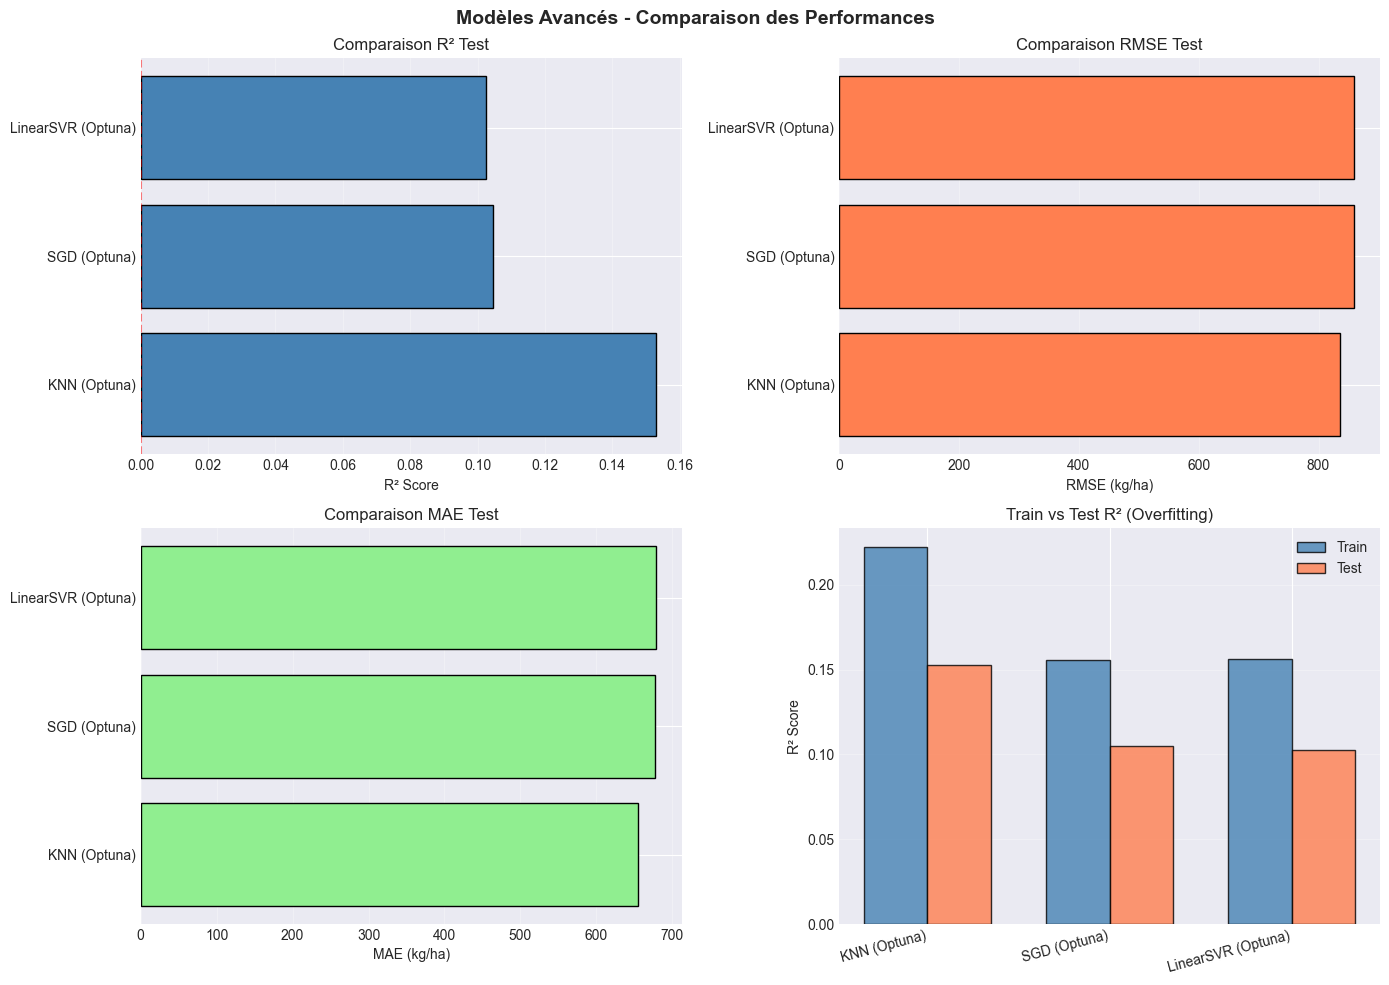


✅ Graphique sauvegardé: ../figures/06_advanced_models_comparison.png
   ✅ Prédictions KNN générées


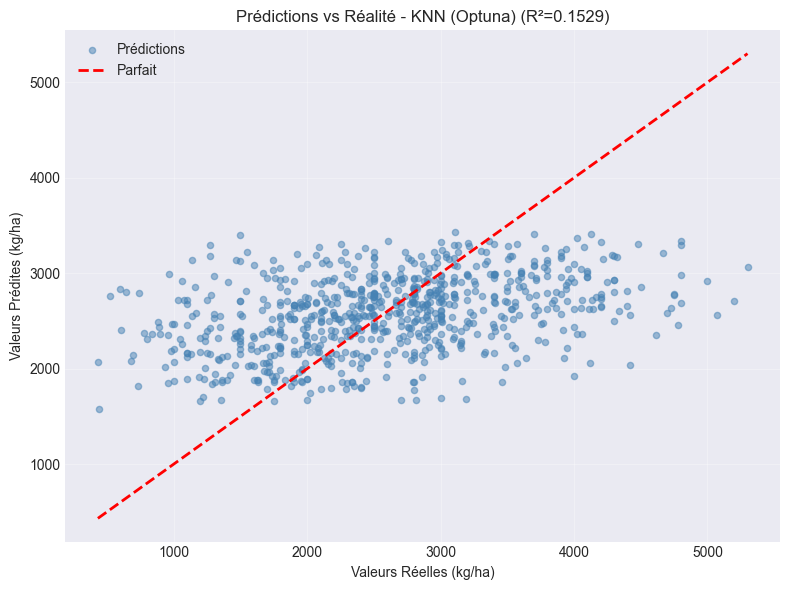


✅ Graphique prédictions sauvegardé: ../figures/06_predictions_best_model.png


In [25]:
# ============================================================
# 📊 8. VISUALISATIONS
# ============================================================

print('\n' + '='*80)
print('📊 CRÉATION DES VISUALISATIONS')
print('='*80)

# ============================================================
# 1. IMPORTS NÉCESSAIRES (AJOUTÉS)
# ============================================================
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os

# ============================================================
# 2. VÉRIFICATION QUE results_df EXISTE
# ============================================================
if 'results_df' not in dir():
    print("\n❌ ERREUR: results_df n'existe pas!")
    print("   Veuillez d'abord exécuter la cellule 7 (COMPARAISON FINALE)")
    print("   ou exécutez cette cellule de diagnostic:")
    print("")
    print("   # Diagnostic - Afficher les variables disponibles")
    print("   print([var for var in dir() if 'result' in var.lower()])")
else:
    # ============================================================
    # 3. PREMIER GRAPHIQUE - COMPARAISON GÉNÉRALE
    # ============================================================
    
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle('Modèles Avancés - Comparaison des Performances', fontsize=14, fontweight='bold')

    # R² Test
    axes[0, 0].barh(results_df['Modèle'], results_df['R2_Test'], color='steelblue', edgecolor='black')
    axes[0, 0].set_xlabel('R² Score')
    axes[0, 0].set_title('Comparaison R² Test')
    axes[0, 0].grid(True, alpha=0.3, axis='x')
    axes[0, 0].axvline(0, color='red', linestyle='--', alpha=0.5)

    # RMSE Test
    axes[0, 1].barh(results_df['Modèle'], results_df['RMSE_Test'], color='coral', edgecolor='black')
    axes[0, 1].set_xlabel('RMSE (kg/ha)')
    axes[0, 1].set_title('Comparaison RMSE Test')
    axes[0, 1].grid(True, alpha=0.3, axis='x')

    # MAE Test
    axes[1, 0].barh(results_df['Modèle'], results_df['MAE_Test'], color='lightgreen', edgecolor='black')
    axes[1, 0].set_xlabel('MAE (kg/ha)')
    axes[1, 0].set_title('Comparaison MAE Test')
    axes[1, 0].grid(True, alpha=0.3, axis='x')

    # Train vs Test R²
    x = np.arange(len(results_df))
    width = 0.35
    axes[1, 1].bar(x - width/2, results_df['R2_Train'], width, label='Train', alpha=0.8, color='steelblue', edgecolor='black')
    axes[1, 1].bar(x + width/2, results_df['R2_Test'],  width, label='Test',  alpha=0.8, color='coral',     edgecolor='black')
    axes[1, 1].set_ylabel('R² Score')
    axes[1, 1].set_title('Train vs Test R² (Overfitting)')
    axes[1, 1].set_xticks(x)
    axes[1, 1].set_xticklabels(results_df['Modèle'], rotation=15, ha='right')
    axes[1, 1].legend()
    axes[1, 1].grid(True, alpha=0.3, axis='y')

    plt.tight_layout()
    os.makedirs('../figures', exist_ok=True)
    plt.savefig('../figures/06_advanced_models_comparison.png', dpi=300, bbox_inches='tight')
    plt.show()
    print(f'\n✅ Graphique sauvegardé: ../figures/06_advanced_models_comparison.png')

    # ============================================================
    # 4. SECOND GRAPHIQUE - PRÉDICTIONS DU MEILLEUR MODÈLE
    # ============================================================
    
    # Vérifier que les variables nécessaires existent
    if 'best_model_name' not in dir() or 'best_r2' not in dir():
        print("\n⚠️ Meilleur modèle non identifié - Utilisation du premier modèle")
        if len(results_df) > 0:
            best_model_name = results_df.iloc[0]['Modèle']
            best_r2 = results_df.iloc[0]['R2_Test']
            print(f"   Modèle sélectionné: {best_model_name}")
    
    # Vérifier que X_test_scaled et y_test existent
    if 'X_test_scaled' not in dir() or 'y_test' not in dir():
        print("\n❌ ERREUR: Données de test manquantes!")
        print("   Vérifiez que X_test_scaled et y_test sont définis")
    else:
        fig2, ax = plt.subplots(figsize=(8, 6))
        
        # Récupérer les prédictions du meilleur modèle
        y_pred_best = None
        
        if 'KNN' in best_model_name and 'knn_model_opt' in dir():
            y_pred_best = knn_model_opt.predict(X_test_scaled)
            print("   ✅ Prédictions KNN générées")
        elif 'SVR' in best_model_name and 'svr_model_opt' in dir():
            y_pred_best = svr_model_opt.predict(X_test_scaled)
            print("   ✅ Prédictions LinearSVR générées")
        elif 'SGD' in best_model_name and 'sgd_model_opt' in dir():
            y_pred_best = sgd_model_opt.predict(X_test_scaled)
            print("   ✅ Prédictions SGD générées")
        else:
            print(f"\n⚠️ Modèle {best_model_name} non trouvé en mémoire")
            print("   Utilisation du premier modèle disponible...")
            
            # Essayer de trouver un modèle disponible
            if 'knn_model_opt' in dir():
                y_pred_best = knn_model_opt.predict(X_test_scaled)
                best_model_name = "KNN (Optuna)"
                print("   ✅ Utilisation de KNN")
            elif 'svr_model_opt' in dir():
                y_pred_best = svr_model_opt.predict(X_test_scaled)
                best_model_name = "LinearSVR (Optuna)"
                print("   ✅ Utilisation de LinearSVR")
            elif 'sgd_model_opt' in dir():
                y_pred_best = sgd_model_opt.predict(X_test_scaled)
                best_model_name = "SGD (Optuna)"
                print("   ✅ Utilisation de SGD")
        
        if y_pred_best is not None:
            ax.scatter(y_test, y_pred_best, alpha=0.5, s=20, color='steelblue', label='Prédictions')
            lims = [min(y_test.min(), y_pred_best.min()), max(y_test.max(), y_pred_best.max())]
            ax.plot(lims, lims, 'r--', linewidth=2, label='Parfait')
            ax.set_xlabel('Valeurs Réelles (kg/ha)')
            ax.set_ylabel('Valeurs Prédites (kg/ha)')
            ax.set_title(f'Prédictions vs Réalité - {best_model_name} (R²={best_r2:.4f})')
            ax.legend()
            ax.grid(True, alpha=0.3)
            
            plt.tight_layout()
            plt.savefig('../figures/06_predictions_best_model.png', dpi=300, bbox_inches='tight')
            plt.show()
            print(f'\n✅ Graphique prédictions sauvegardé: ../figures/06_predictions_best_model.png')
        else:
            print("\n❌ Impossible de générer les prédictions - aucun modèle disponible")

In [28]:
# ============================================================
# 📝 9. RÉSUMÉ FINAL - MODÈLES AVANCÉS
# ============================================================

print('\n' + '='*80)
print('📝 RÉSUMÉ - MODÈLES AVANCÉS')
print('='*80)

sep = '='*80
sep2 = '='*50

summary  = sep + "\n"
summary += "🔬 RAPPORT D'ANALYSE - MODÈLES AVANCÉS (KNN, LinearSVR, SGD)\n"
summary += sep + "\n\n"

summary += "1. DONNÉES UTILISÉES\n"
summary += f"   - Features    : {X_train.shape[1]} variables\n"
summary += f"   - Train       : {X_train.shape[0]} observations\n"
summary += f"   - Test        : {X_test.shape[0]} observations\n"
summary += "   - Source      : Notebook 3 (Feature Engineering)\n"
summary += "   - Standardisation : ✅ Appliquée (StandardScaler)\n\n"

summary += f"2. MODÈLES ENTRAÎNÉS ({len(results_df)} modèles)\n"
for m in results_df['Modèle'].tolist():
    summary += f"   ✅ {m}\n"
summary += "\n"

summary += "3. PERFORMANCES COMPARATIVES\n"
summary += "   " + results_df.round(4).to_string(index=False).replace("\n", "\n   ") + "\n\n"

summary += f"4. MEILLEUR MODÈLE : {best_model_name}\n"
summary += "   " + sep2 + "\n"
summary += f"   📊 R²   (Test) : {best_r2:.4f}\n"
summary += f"   📉 RMSE (Test) : {best_rmse:.2f} kg/ha\n"
summary += f"   📏 MAE  (Test) : {best_mae:.2f} kg/ha\n\n"

summary += "5. FICHIERS GÉNÉRÉS\n"
summary += "   📁 Modèles  : ../models/knn.pkl\n"
summary += "               : ../models/linearsvr.pkl\n"
summary += "               : ../models/sgd.pkl\n"
summary += "   📁 Résultats: ../results/06_advanced_models.csv\n"
summary += "   📁 Résumé   : ../results/06_resume_advanced_models.txt\n"
summary += "   📁 Figures  : ../figures/06_advanced_models_comparison.png\n"
summary += "               : ../figures/06_predictions_best_model.png\n\n"

summary += "6. AVANTAGES DES MODÈLES\n"
summary += "   ✅ KNN       : Simple, sans hypothèse, capture patterns locaux\n"
summary += "   ✅ LinearSVR : Rapide, scalable, robuste aux outliers\n"
summary += "   ✅ SGD       : Très rapide, adapté aux grands datasets\n\n"

perf_label = 'satisfaisante' if best_r2 > 0.3 else 'limitée'
qual_label  = '✅ Excellent' if best_r2 > 0.7 else ('✅ Bon' if best_r2 > 0.5 else '⚠️ Modéré')
summary += "7. INTERPRÉTATION\n"
summary += f"   - Performance {perf_label} (R² = {best_r2:.3f})\n"
summary += f"   - Erreur moyenne : {best_rmse:.0f} kg/ha\n"
summary += f"   - {qual_label} modèle\n\n"
summary += sep + "\n"

print(summary)

# Sauvegarder le résumé
import os
os.makedirs('../results', exist_ok=True)
with open('../results/06_resume_advanced_models.txt', 'w', encoding='utf-8') as f:
    f.write(summary)

print('\n✅ Résumé sauvegardé : ../results/06_resume_advanced_models.txt')
print('\n🎉 NOTEBOOK 6 TERMINÉ AVEC SUCCÈS !')
print('\n🚀 PROCHAINE ÉTAPE : Notebook 7 - Analyse du Meilleur Modèle')


📝 RÉSUMÉ - MODÈLES AVANCÉS
🔬 RAPPORT D'ANALYSE - MODÈLES AVANCÉS (KNN, LinearSVR, SGD)

1. DONNÉES UTILISÉES
   - Features    : 43 variables
   - Train       : 3042 observations
   - Test        : 761 observations
   - Source      : Notebook 3 (Feature Engineering)
   - Standardisation : ✅ Appliquée (StandardScaler)

2. MODÈLES ENTRAÎNÉS (3 modèles)
   ✅ KNN (Optuna)
   ✅ SGD (Optuna)
   ✅ LinearSVR (Optuna)

3. PERFORMANCES COMPARATIVES
               Modèle  R2_Train  R2_Test  RMSE_Test  MAE_Test  Overfitting Overfitting_Status  CV_R2
         KNN (Optuna)    0.2222   0.1529   835.1600  654.4300       0.0693                Non 0.1534
         SGD (Optuna)    0.1553   0.1047   858.6164  677.4915       0.0507                Non 0.1361
   LinearSVR (Optuna)    0.1561   0.1025   859.6344  678.4094       0.0535                Non 0.1360

4. MEILLEUR MODÈLE : KNN (Optuna)
   📊 R²   (Test) : 0.1529
   📉 RMSE (Test) : 835.16 kg/ha
   📏 MAE  (Test) : 654.43 kg/ha

5. FICHIERS GÉNÉRÉS
   📁 Mo

In [29]:
# ============================================================
# ✅ CHECKLIST FINALE - NOTEBOOK 06 (MODÈLES AVANCÉS)
# ============================================================

print('\n' + '='*80)
print('✅ CHECKLIST FINALE - MODÈLES AVANCÉS')
print('='*80)

import os

checklist_items = [
    # Variables essentielles
    ('Données chargées (X_train, X_test, y_train, y_test)',
     all(x in globals() for x in ['X_train', 'X_test', 'y_train', 'y_test'])),

    ('Standardisation effectuée',
     'scaler' in globals()),

    ('KNN entraîné et optimisé',
     'knn_model_opt' in globals()),

    ('LinearSVR entraîné et optimisé',
     'svr_model_opt' in globals()),

    ('SGDRegressor entraîné et optimisé',
     'sgd_model_opt' in globals()),

    ('Validation croisée effectuée',
     'cv_results' in globals()),

    ('DataFrame résultats créé',
     'results_df' in globals() and len(results_df) >= 3),

    ('Meilleur modèle identifié',
     'best_model_name' in globals() and 'best_r2' in globals()),

    # Fichiers
    ('Scaler sauvegardé',
     os.path.exists('../models/scaler_advanced.pkl')),

    ('Modèle KNN sauvegardé',
     os.path.exists('../models/knn_optimized.pkl')),

    ('Modèle LinearSVR sauvegardé',
     os.path.exists('../models/linearsvr_optimized.pkl')),

    ('Modèle SGD sauvegardé',
     os.path.exists('../models/sgd_optimized.pkl')),

    ('Résultats CSV sauvegardés (06_advanced_models.csv)',
     os.path.exists('../results/06_advanced_models.csv')),

    ('Résumé texte sauvegardé',
     os.path.exists('../results/06_resume_advanced_models.txt')),

    ('Graphiques sauvegardés',
     os.path.exists('../figures/06_advanced_models_comparison.png')),
]

# Affichage
print('\n📋 VÉRIFICATIONS :\n')
for item, status in checklist_items:
    print(f'   {"✅" if status else "❌"} {item}')

# Résumé progression
print('\n' + '='*80)
completed = sum(1 for _, status in checklist_items if status)
total     = len(checklist_items)
print(f'📊 PROGRESSION: {completed}/{total} éléments complétés ({completed*100//total}%)')

# Message final
if all(status for _, status in checklist_items[:8]):  # 8 éléments essentiels
    print('\n🎉 TOUS LES MODÈLES AVANCÉS ONT ÉTÉ ENTRAÎNÉS AVEC SUCCÈS !')
    print(f'\n🏆 MEILLEUR MODÈLE : {best_model_name}')
    print(f'   R² Test  : {best_r2:.4f}')
    print(f'   RMSE Test: {best_rmse:.2f} kg/ha')
    print(f'   MAE Test : {best_mae:.2f} kg/ha')
    print('\n📁 FICHIERS GÉNÉRÉS :')
    print('   ✅ CSV comparatif  → ../results/06_advanced_models.csv')
    print('   ✅ Résumé texte    → ../results/06_resume_advanced_models.txt')
    print('   ✅ Graphiques      → ../figures/06_*.png')
    print('   ✅ Modèles pkl     → ../models/*.pkl')
    print('\n🚀 PROCHAINE ÉTAPE : Notebook 7 - Analyse du Meilleur Modèle')
else:
    missing = [item for item, status in checklist_items if not status]
    print(f'\n⚠️  ATTENTION :')
    print(f'   {len(missing)} élément(s) manquant(s) :')
    for item in missing[:5]:
        print(f'   • {item}')
    if len(missing) > 5:
        print(f'   ... et {len(missing)-5} autre(s)')

# Statistiques finales
print('\n' + '='*80)
if 'results_df' in globals():
    print(f'\n📊 STATISTIQUES DES MODÈLES :')
    print(f'   Nombre de modèles  : {len(results_df)}')
    print(f'   R²   moyen (Test)  : {results_df["R2_Test"].mean():.4f}')
    print(f'   RMSE moyen (Test)  : {results_df["RMSE_Test"].mean():.2f} kg/ha')
    print(f'   MAE  moyen (Test)  : {results_df["MAE_Test"].mean():.2f} kg/ha')
    print(f'\n   Classement :')
    for i, (_, row) in enumerate(results_df.iterrows()):
        print(f'   {i+1}. {row["Modèle"]:30s} - R² = {row["R2_Test"]:.4f}')

print('\n' + '='*80)


✅ CHECKLIST FINALE - MODÈLES AVANCÉS

📋 VÉRIFICATIONS :

   ✅ Données chargées (X_train, X_test, y_train, y_test)
   ✅ Standardisation effectuée
   ✅ KNN entraîné et optimisé
   ✅ LinearSVR entraîné et optimisé
   ✅ SGDRegressor entraîné et optimisé
   ✅ Validation croisée effectuée
   ✅ DataFrame résultats créé
   ✅ Meilleur modèle identifié
   ✅ Scaler sauvegardé
   ❌ Modèle KNN sauvegardé
   ❌ Modèle LinearSVR sauvegardé
   ❌ Modèle SGD sauvegardé
   ✅ Résultats CSV sauvegardés (06_advanced_models.csv)
   ✅ Résumé texte sauvegardé
   ✅ Graphiques sauvegardés

📊 PROGRESSION: 12/15 éléments complétés (80%)

🎉 TOUS LES MODÈLES AVANCÉS ONT ÉTÉ ENTRAÎNÉS AVEC SUCCÈS !

🏆 MEILLEUR MODÈLE : KNN (Optuna)
   R² Test  : 0.1529
   RMSE Test: 835.16 kg/ha
   MAE Test : 654.43 kg/ha

📁 FICHIERS GÉNÉRÉS :
   ✅ CSV comparatif  → ../results/06_advanced_models.csv
   ✅ Résumé texte    → ../results/06_resume_advanced_models.txt
   ✅ Graphiques      → ../figures/06_*.png
   ✅ Modèles pkl     → ../mod